##### ### The University of Melbourne, School of Computing and Information Systems
# COMP30027 Machine Learning, 2026 Semester 1

## Assignment 1: Income Classification with Naïve Bayes


**Student ID(s):**     `1617188`

This iPython notebook is a template which you will use for your Assignment 1 submission.

**NOTE: YOU SHOULD ADD YOUR RESULTS, GRAPHS, AND FIGURES FROM YOUR OBSERVATIONS IN THIS FILE TO YOUR REPORT (the PDF file).** Results, figures, etc. which appear in this file but are NOT included in your report will not be marked.

**Adding proper comments to your code is MANDATORY. **

## 0. Setting up

### Importing libraries and defining constants

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.preprocessing import OrdinalEncoder
from scipy.stats import norm
from sklearn.metrics import (accuracy_score, 
                             classification_report, 
                             confusion_matrix, 
                             ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split

# Define column names and target variable
CONTINUOUS = ['age', 'education-num', 'capital-gain',
              'capital-loss', 'hours-per-week']
 
CATEGORICAL = ['workclass', 'education', 'marital-status',
               'occupation', 'relationship', 'race',
               'sex', 'native-country']
 
TARGET = 'income'

ALL_FEATURES = CONTINUOUS + CATEGORICAL

### Creating helper functions

In [2]:
def load_data(path, has_labels=True):
    """ 
    Load data from a CSV into a pandas DataFrame and perform preprocessing steps.
    """

    # 1. Load data 
    df = pd.read_csv(path) 

    # 2. Drop 'fnlwgt' column as it is not a meaningful characteristic of the individual.
    if 'fnlwgt' in df.columns:
        df.drop(columns=['fnlwgt'], inplace=True) 
    
    # 3. Drop rows with any missing values.
    df = df.dropna(subset=ALL_FEATURES)

    # 4. Convert target variable to binary labels (1 for '>50K', 0 for '<=50K').
    if has_labels:
        df[TARGET] = df[TARGET].apply(lambda x: 1 if x == '>50K' else 0)
    
    return df

def build_and_train_model(train_df):
    """
    Build and train a Naive Bayes classifier using the training data.
    """

    # Separate features and target variable
    x_continuous = train_df[CONTINUOUS].values
    x_categorical = train_df[CATEGORICAL]
    y_train = train_df[TARGET].values

    encoder = OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    )

    x_categorical_encoded = encoder.fit_transform(x_categorical)

    gnb = GaussianNB()
    gnb.fit(x_continuous, y_train)

    min_categories = [len(cats) for cats in encoder.categories_]
    cnb = CategoricalNB(alpha=1.0,min_categories=min_categories)
    cnb.fit(x_categorical_encoded, y_train)

    cat_vocab = {feat: encoder.categories_[i] for i, feat in enumerate(CATEGORICAL)}

    return gnb, cnb, encoder, cat_vocab

def predict_combined(gnb, cnb, encoder, df):
    """
    Predict labels and log-posteriors by combining both NB models.
    """
    x_continuous = df[CONTINUOUS].values
    x_categorical = encoder.transform(df[CATEGORICAL])

    n=len(df)
    n_classes = len(gnb.classes_)

    log_post = gnb.predict_log_proba(x_continuous)

    for i, feat in enumerate(CATEGORICAL):
        n_categories = len(encoder.categories_[i])
        col = x_categorical[:, i].astype(int)
        oov_mask = (col == -1)

        feat_probs = cnb.feature_log_prob_[i]
        alpha = cnb.alpha
        oov_log_prob = np.log(alpha) - np.log(cnb.class_count_ + alpha * n_categories)

        for c_idx in range(n_classes):
            class_feat_lp = feat_probs[c_idx, :]

            contribution = np.where(
                oov_mask,
                oov_log_prob[c_idx],
                class_feat_lp[np.clip(col, 0, n_categories - 1)]
            )

            log_post[:, c_idx] += contribution
        
        y_pred = np.argmax(log_post, axis=1)
    return y_pred, log_post

def posterior_ratio(log_post):
    """
    Compute R = P(>50K|x) / P(<=50K|x) from log posteriors.
    """
    lp = log_post - log_post.max(axis=1, keepdims=True)
    proba = np.exp(lp)
    proba /= proba.sum(axis=1, keepdims=True)
    R = proba[:, 1] / np.maximum(proba[:, 0], 1e-300)
    return R


## 1. Supervised model training


In [3]:
# Import training dataset
train_df = load_data('data/adult_supervised_train.csv', has_labels=True)

# Training Q1 model
# gnb = GaussianNB: handles continuous features
# cnb = CategoricalNB: handles categorical features
# encoder = OrdinalEncoder to convert categorical features to numerical values for CategoricalNB
# cat_vocab = dictionary {feature: array of unknown values}
gnb, cnb, encoder, cat_vocab = build_and_train_model(train_df)


# print(pd.read_csv("data/adult_supervised_train.csv").isna().sum())
# print("---")
# print((pd.read_csv("data/adult_supervised_train.csv")=='?').sum())


**Question 1.1** <br>
What are the prior probabilities of the two classes P(c) in the training data? Does the training set exhibit class imbalance, and if so, what effect might this hav on classifier behaviour?

P(c = '<=50K ') = 0.7541, (count=11369.0)
P(c = '>50K  ') = 0.2459, (count=3707.0)

Imbalance Ratio (<=50K : >50K) = 3.07 : 1
Majority class is '<=50K'.


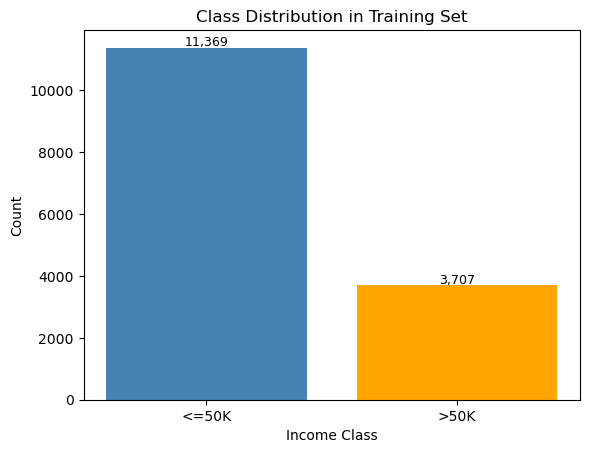

In [4]:
# Iterates over the classes, their counts, and prior probabilities to print the class distribution.
for c, count, prior in zip(gnb.classes_, gnb.class_count_, gnb.class_prior_):
    label = '>50K' if c == 1 else '<=50K'
    print(f"P(c = '{label:6}') = {prior:.4f}, (count={count})")

# Calculate the ratio of the majority to the minority to identify imbalance.
imbalance_ratio = gnb.class_count_[0] / gnb.class_count_[1]
print(f"\nImbalance Ratio (<=50K : >50K) = {imbalance_ratio:.2f} : 1")

# Identify the majority class based on class counts.
print(f"Majority class is '{'>50K' if gnb.class_count_[1] > gnb.class_count_[0] else '<=50K'}'.")

fig, ax = plt.subplots()
ax.bar(['<=50K', '>50K'], 
       gnb.class_count_,
       color=['steelblue', 'orange'] 
       )
ax.set_title('Class Distribution in Training Set')
ax.set_xlabel('Income Class')
ax.set_ylabel('Count')
for i, v in enumerate(gnb.class_count_):
    ax.text(i, v + 50, f'{int(v):,}', ha='center', fontsize=9)
plt.savefig('figures/fig_1.1_class_distribution.png', dpi=300)
plt.show()

**Question 1.2**<br>
For each continuous feature, report the estimated mean and standard deviation for each class. Which continuous features show the greatest seperation between classes? Do these seem intuitively reasonable given the nature of the feature?

       Feature  Mean (<=50K)  Std (<=50K)  Mean (>50K)   Std (>50K)  Separation (d)
 education-num      9.629255     2.447812    11.594551     2.364977        0.816697
           age     37.050752    13.711919    43.938495    10.302703        0.573629
hours-per-week     39.428622    11.910803    45.642298    10.396091        0.557108
  capital-gain    157.666022  1017.863238  3607.146749 13616.622967        0.471418
  capital-loss     55.974580   316.020139   202.362018   603.991020        0.318230


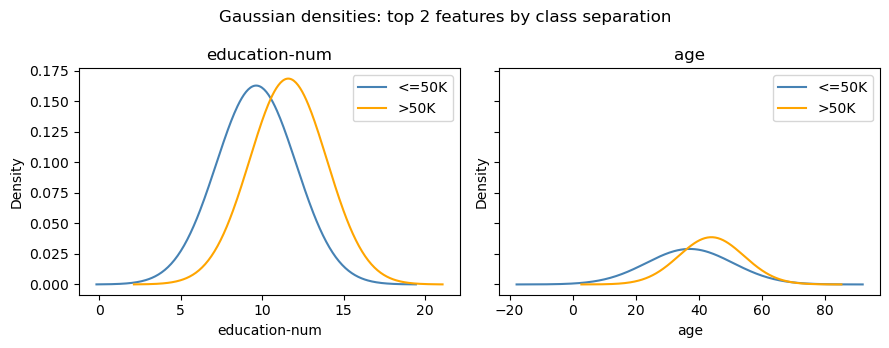

In [5]:
rows = []
for i, feat in enumerate(CONTINUOUS):
    mean0, std0 = gnb.theta_[0][i], np.sqrt(gnb.var_[0][i])
    mean1, std1 = gnb.theta_[1][i], np.sqrt(gnb.var_[1][i])
    average_std = (std0 + std1) / 2
    seperation = abs(mean1 - mean0) / average_std if average_std > 0 else 0
    rows.append({
        'Feature': feat,
        'Mean (<=50K)': mean0,
        'Std (<=50K)': std0,
        'Mean (>50K)': mean1,
        'Std (>50K)': std1,
        'Separation (d)': seperation
    })

gauss_table = pd.DataFrame(rows).sort_values('Separation (d)', ascending=False)
print(gauss_table.to_string(index=False))

top2 = gauss_table.head(2)['Feature'].tolist()
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), sharey=True)
for ax, feat in zip(axes, top2):
    i = CONTINUOUS.index(feat)
    for c_idx, col, label in zip([0, 1], ['steelblue', 'orange'], ['<=50K', '>50K']):
        mu = gnb.theta_[c_idx, i]
        std = np.sqrt(gnb.var_[c_idx, i])
        x = np.linspace(mu - 4*std, mu + 4*std, 300)
        ax.plot(x, norm.pdf(x, mu, std), color=col, label=label)
        ax.set_title(feat)  
        ax.set_xlabel(feat)
        ax.set_ylabel('Density')
        ax.legend()
plt.suptitle('Gaussian densities: top 2 features by class separation')
plt.tight_layout()
plt.savefig('figures/fig_1.2_gaussian_densities.png', dpi=150)
plt.show()

**Question 1.3**<br>

For each categorical feature, identify the category value most strongly predicteve of each class. One way to measure this is the probability ratio:<br>

$$
R = \frac{P(x_j = v \mid c_1)}{P(x_j = v \mid c_2)}
$$

In [6]:
ratios = []

for i, feat in enumerate(CATEGORICAL):
    categories = encoder.categories_[i]
    feat_probs = cnb.feature_log_prob_[i]
    lp0 = feat_probs[0, :]   # <=50K
    lp1 = feat_probs[1, :]   # >50K
    for j, v in enumerate(categories):
        ratios.append({'Feature': feat, 'Value': v, 'R': round(np.exp(lp1[j] - lp0[j]), 4)})
    
ratio_df = pd.DataFrame(ratios)

print('\n  Top 5 most predictive of >50K  (highest R):')
print(ratio_df.nlargest(5, 'R')[['Feature', 'Value', 'R']].to_string(index=False))

print('\n  Top 5 most predictive of <=50K  (lowest R):')
print(ratio_df.nsmallest(5, 'R')[['Feature', 'Value', 'R']].to_string(index=False))


  Top 5 most predictive of >50K  (highest R):
       Feature             Value      R
     education       Prof-school 7.9587
     education         Doctorate 7.1354
marital-status Married-AF-spouse 4.2882
     education           Masters 3.5551
native-country            Taiwan 3.3832

  Top 5 most predictive of <=50K  (lowest R):
     Feature           Value      R
relationship       Own-child 0.0522
  occupation Priv-house-serv 0.0838
  occupation   Other-service 0.1354
relationship  Other-relative 0.1445
   education             9th 0.1508


## 2. Supervised model evaluation

In [7]:
test_df = load_data('data/adult_test.csv', has_labels=True)
y_test = test_df[TARGET].values

y_pred_q1, log_post_q1 = predict_combined(gnb, cnb, encoder, test_df)
R_q1 = posterior_ratio(log_post_q1)


**Question 2.1**<br>
Report the overall accuracy of your classifier as well as a class-level breakdown. Include a confusion matric and report precision, recall, and F1-score for each class.

Overall Accuracy: 0.8307
Accuracy for '>50K': 0.5254
Accuracy for '<=50K': 0.9329
--------------------------------
              precision    recall  f1-score   support

           0     0.8545    0.9329    0.8920     11303
           1     0.7240    0.5254    0.6089      3784

    accuracy                         0.8307     15087
   macro avg     0.7892    0.7292    0.7504     15087
weighted avg     0.8217    0.8307    0.8210     15087



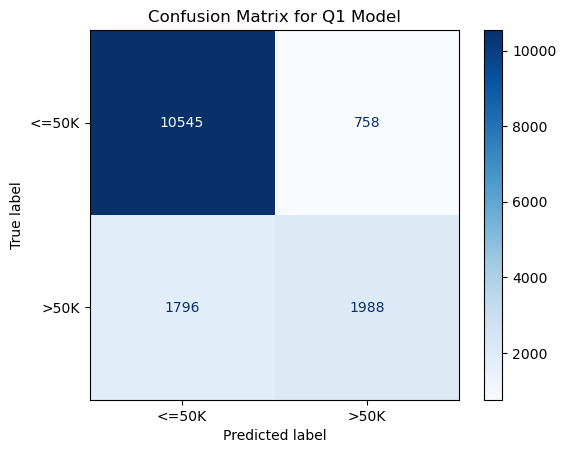

In [8]:
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_q1):.4f}")
print(f"Accuracy for '>50K': {accuracy_score(y_test[y_test == 1], y_pred_q1[y_test == 1]):.4f}")
print(f"Accuracy for '<=50K': {accuracy_score(y_test[y_test == 0], y_pred_q1[y_test == 0]):.4f}")
print("--------------------------------")
print(classification_report(y_test, y_pred_q1, digits=4))

fig, ax = plt.subplots()
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_q1),
    display_labels=['<=50K', '>50K']
).plot(ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix for Q1 Model')
plt.savefig('figures/fig_1.3_confusion_matrix.png', dpi=300)
plt.show()


**Question 2.2**<br>
Out-of-vocabulary / unseen categories: some categorical feature values in the test set may not have appeard during training. Report how many test instances contain at least one unseen category value, and describe how your implementation handles them (e.g., via Laplace smoothing, or by skipping the feature entirely). Were any test instances skipped entirely because they could not be classified?

In [9]:
x_category_test = encoder.transform(test_df[CATEGORICAL])

oov_per_feature = {}
for i, feat in enumerate(CATEGORICAL):
    n_oov = (x_category_test[:, i] == -1).sum()
    if n_oov > 0:
        oov_per_feature[feat] = n_oov

oov_row_mask = (x_category_test == -1).any(axis=1)
print(f'\nRows with ≥1 OOV category : {oov_row_mask.sum():,} ({100*oov_row_mask.mean():.1f}%)')

if oov_per_feature:
    for feat, cnt in sorted(oov_per_feature.items(), key=lambda x: -x[1]):
        print(f"{feat}: {cnt} OOV instances")
else:
    print("No OOV values in the test set.")


Rows with ≥1 OOV category : 1 (0.0%)
native-country: 1 OOV instances


**Q2.3**<br>
Provide examples of instances classified with high and low confidence. The confidence of a prediction can be measured using the posterior ratio:<br>
$$
R = \frac{P(c_1 \mid x)}{P(c_2 \mid x)}
$$



In [10]:
result_df = test_df[ALL_FEATURES].copy()
result_df['true']   = y_test
result_df['pred']   = y_pred_q1
result_df['R']      = R_q1

# 1. Define specific columns that tell a clear story for the report
report_cols = ['age', 'education', 'occupation', 'capital-gain', 'hours-per-week', 'marital-status', 'true', 'pred', 'R']

# 2. Fix the Near-Boundary Logic
# We find indices where the absolute difference between R and 1.0 is minimized
boundary_idx = (result_df['R'] - 1.0).abs().argsort()[:3]

print('\nTop 3 Confident >50K (Largest R):')
print(result_df[result_df['pred'] == 1].nlargest(3, 'R')[report_cols].to_string(index=False))

print('Top 3 Confident <=50K (Smallest R):')
print(result_df[result_df['pred'] == 0].nsmallest(3, 'R')[report_cols].to_string(index=False))

print('Top 3 Near-Boundary (R ≈ 1):')
print(result_df.iloc[boundary_idx][report_cols].to_string(index=False))


Top 3 Confident >50K (Largest R):
 age   education      occupation  capital-gain  hours-per-week     marital-status  true  pred             R
  50 Prof-school  Prof-specialty         99999              80 Married-civ-spouse     1     1 1.000000e+300
  41   Doctorate  Prof-specialty         99999              70 Married-civ-spouse     1     1 1.000000e+300
  47     Masters Exec-managerial         99999              50 Married-civ-spouse     1     1 1.000000e+300
Top 3 Confident <=50K (Smallest R):
 age education    occupation  capital-gain  hours-per-week marital-status  true  pred            R
  18      10th Other-service             0               3  Never-married     0     0 9.242193e-10
  17      10th Other-service             0              12  Never-married     0     0 1.074523e-09
  17      11th Other-service             0               5  Never-married     0     0 1.107104e-09
Top 3 Near-Boundary (R ≈ 1):
 age education      occupation  capital-gain  hours-per-week     marital

## 3. Extending the model with semi-supervised training

threshold=  1.5  n_pseudo=14,632  val_acc=0.8067
threshold=  2.0  n_pseudo=14,355  val_acc=0.8067
threshold=  3.0  n_pseudo=13,880  val_acc=0.8070
threshold=  5.0  n_pseudo=13,288  val_acc=0.8064
threshold= 10.0  n_pseudo=12,460  val_acc=0.8060
threshold= 20.0  n_pseudo=11,482  val_acc=0.8107
threshold= 99.0  n_pseudo= 9,615  val_acc=0.8206

Selected threshold: 99.0


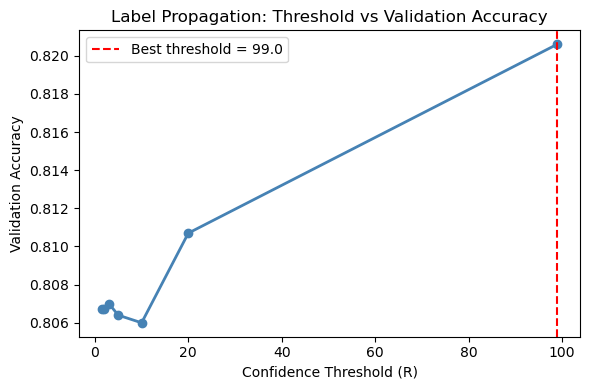

In [11]:
# Load unlabelled dataset (no income column)
unlabeled_df = load_data('data/adult_unlabelled.csv', has_labels=False)

# Create validation split (stratified, 80/20) from supervised training data
train_sub, val_sub = train_test_split(
    train_df, test_size=0.2, random_state=42, stratify=train_df[TARGET]
)

def run_label_propagation(sup_df, unlabeled_df, r_threshold):
    """
    Confidence-thresholded label propagation:
      1. Train model on sup_df
      2. Pseudo-label unlabeled_df instances with |log R| > threshold
      3. Retrain on sup_df + pseudo-labelled subset
    Returns the new model components and number of pseudo-labelled instances.
    """
    # Step 1: train base model on labelled data
    gnb1, cnb1, encoder1, _ = build_and_train_model(sup_df)

    # Step 2: predict pseudo-labels for unlabelled data
    pseudo_pred, pseudo_lp = predict_combined(gnb1, cnb1, encoder1, unlabeled_df)
    R_unlab = posterior_ratio(pseudo_lp)

    # Keep only high-confidence predictions (R > threshold OR R < 1/threshold)
    confident_mask = (R_unlab > r_threshold) | (R_unlab < 1.0 / r_threshold)
    pseudo_df = unlabeled_df[ALL_FEATURES][confident_mask].copy()
    pseudo_df[TARGET] = pseudo_pred[confident_mask]

    # Step 3: retrain on combined labelled + pseudo-labelled data
    combined_df = pd.concat([sup_df, pseudo_df], ignore_index=True)
    gnb2, cnb2, encoder2, _ = build_and_train_model(combined_df)

    return gnb2, cnb2, encoder2, combined_df, confident_mask.sum()


# Hyperparameter search: evaluate each threshold on the validation split
thresholds = [1.5, 2.0, 3.0, 5.0, 10.0, 20.0, 99.0]
val_y = val_sub[TARGET].values
threshold_results = []

for t in thresholds:
    g, c, e, comb, n_ps = run_label_propagation(train_sub, unlabeled_df, t)
    yv, _ = predict_combined(g, c, e, val_sub)
    acc = accuracy_score(val_y, yv)
    threshold_results.append({'threshold': t, 'n_pseudo': n_ps, 'val_acc': round(acc, 4)})
    print(f"threshold={t:5.1f}  n_pseudo={n_ps:6,}  val_acc={acc:.4f}")

# Select best threshold
best_t = max(threshold_results, key=lambda x: x['val_acc'])['threshold']
print(f"\nSelected threshold: {best_t}")

val_accs = [r['val_acc'] for r in threshold_results]
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(thresholds, val_accs, marker='o', color='steelblue', linewidth=2)
ax.axvline(best_t, color='red', linestyle='--', label=f'Best threshold = {best_t}')
ax.set_xlabel('Confidence Threshold (R)')
ax.set_ylabel('Validation Accuracy')
ax.set_title('Label Propagation: Threshold vs Validation Accuracy')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig_3.1_threshold_tuning.png', dpi=150)
plt.show()

In [12]:
gnb_q3, cnb_q3, encoder_q3, combined_df_q3, n_pseudo_final = run_label_propagation(
    train_df, unlabeled_df, best_t
)

print(f"Pseudo-labelled instances added: {n_pseudo_final:,}")
print(f"Original supervised training: {len(train_df):,}")
print(f"Combined training set size: {len(combined_df_q3):,}")
pseudo_class_counts = combined_df_q3[TARGET][len(train_df):].value_counts()
print(f"Pseudo-label class distribution: {dict(pseudo_class_counts)}")


Pseudo-labelled instances added: 9,676
Original supervised training: 15,076
Combined training set size: 24,752
Pseudo-label class distribution: {0: 8289, 1: 1387}


## 4. Supervised model evaluation

In [16]:
test_df = load_data('data/adult_test.csv', has_labels=True)
y_test = test_df[TARGET].values

y_pred_q1, log_post_q1 = predict_combined(gnb, cnb, encoder, test_df)
y_pred_q3, log_post_q3 = predict_combined(gnb_q3, cnb_q3, encoder_q3, test_df)

R_q1 = posterior_ratio(log_post_q1)
R_q3 = posterior_ratio(log_post_q3)

print("Q1 Model Performance:")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_q1):.4f}")
print(classification_report(y_test, y_pred_q1, digits=4, target_names=['<=50K', '>50K']))

print("Q3 Model Performance:")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_q3):.4f}")
print(classification_report(y_test, y_pred_q3, digits=4, target_names=['<=50K', '>50K']))

Q1 Model Performance:
Overall Accuracy: 0.8307
              precision    recall  f1-score   support

       <=50K     0.8545    0.9329    0.8920     11303
        >50K     0.7240    0.5254    0.6089      3784

    accuracy                         0.8307     15087
   macro avg     0.7892    0.7292    0.7504     15087
weighted avg     0.8217    0.8307    0.8210     15087

Q3 Model Performance:
Overall Accuracy: 0.8190
              precision    recall  f1-score   support

       <=50K     0.8462    0.9269    0.8847     11303
        >50K     0.6948    0.4968    0.5794      3784

    accuracy                         0.8190     15087
   macro avg     0.7705    0.7119    0.7320     15087
weighted avg     0.8082    0.8190    0.8081     15087



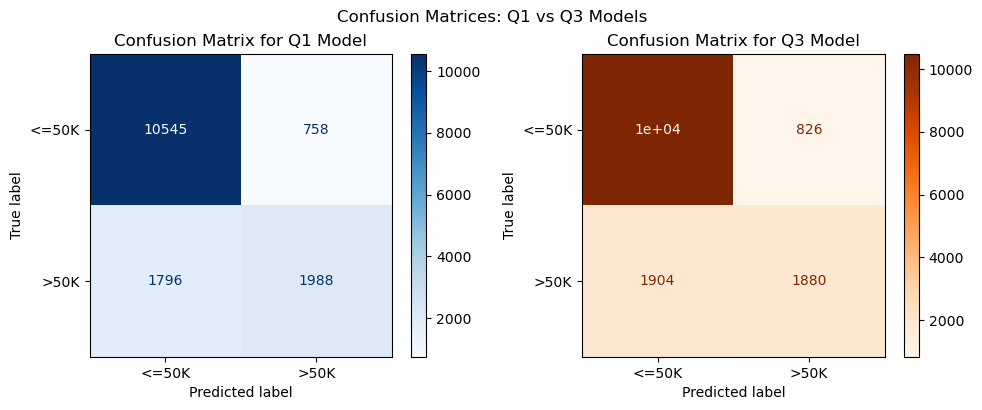

In [23]:
fix, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_pred, title, cmap in zip(
    axes,
    [y_pred_q1, y_pred_q3],
    ['Q1 Model', 'Q3 Model'],
    ['Blues', 'Oranges']
):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=['<=50K', '>50K']
    ).plot(ax=ax, cmap=cmap)
    ax.set_title(f'Confusion Matrix for {title}')
plt.suptitle("Confusion Matrices: Q1 vs Q3 Models")
plt.tight_layout()
plt.savefig('figures/fig_4.1_confusion_matrices_comparison.png', dpi=300)
plt.show()